In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
data = pd.read_excel("consolidado_ucn_con_datos.xlsx", sheet_name=1, header= 3)
data.head()

,id_registro,id_persona,rut,nombre_consolidado,tipo_persona,facultad,unidad,doi,titulo,anio,indice_fuente,autor_como_aparece,afiliacion_detectada,match_status,metodo_match,orcid,scopus_author_id,wos_researcher_id
0,SCOPUS-2-s2.0-105001973866-1,AUT-01900,21194929-5,"ATIENZA UBEDA, MIGUEL",Interno UCN,NaN,Departamento de Economía,10.1080/00343404.2024.2342445,(Un)linking industrial path development and de...,2025,Scopus,"Atienza, M.",University of Cologne| Universidad Católica de...,Confirmado,scopus_author_id,0000-0003-3202-574X,58035809500,NaN
1,SCOPUS-2-s2.0-105001973866-2,AUT-02737,10799364-9,"LUFIN VARAS, MARCELO LEONARDO",Interno UCN,NaN,Departamento de Economía,10.1080/00343404.2024.2342445,(Un)linking industrial path development and de...,2025,Scopus,"Lufin, M.",University of Cologne| Universidad Católica de...,Confirmado,scopus_author_id,0000-0002-6856-6401,55649223100,DTV-4850-2022
2,SCOPUS-2-s2.0-105022833319-1,AUT-01268,18709131-4,"CARVAJAL SAPIAIN, FRANCHESCA NICOLE",Interno UCN,NaN,Departamento Gestion de la Construccion,-,02-027 – Conceptual model for the adoption of ...,2025,Scopus,"Carvajal Sapiain, F.",Universidad Católica del Norte,Confirmado,scopus_author_id,NaN,60209886400,NaN
3,SCOPUS-2-s2.0-105022833319-2,AUT-01725,14695749-8,"HEREDIA ROJAS, BORIS FABRIZIO",Interno UCN,NaN,Departamento Gestion de la Construccion,-,02-027 – Conceptual model for the adoption of ...,2025,Scopus,"Heredia Rojas, B.",Universidad Católica del Norte,Confirmado,scopus_author_id,0000-0003-4134-5569,57191038673,NaN
4,SCOPUS-2-s2.0-85217077735-4,AUT-01220,28196915-3,"FERNANDEZ, FABRICIO",Externo UCN,NaN,Departamento Ingenieria Civil,10.1139/cgj-2024-0044,3D large deformation modeling of the 2020 Gjer...,2025,Scopus,"Fernández, F.",Norwegian University of Science and Technology...,Confirmado,scopus_author_id,0000-0001-7523-5961,57212385250,AAX-5566-2021


In [20]:
data.isna().count()

id_registro             1774
id_persona              1774
rut                     1774
nombre_consolidado      1774
tipo_persona            1774
facultad                1774
unidad                  1774
doi                     1774
titulo                  1774
anio                    1774
indice_fuente           1774
autor_como_aparece      1774
afiliacion_detectada    1774
match_status            1774
metodo_match            1774
orcid                   1774
scopus_author_id        1774
wos_researcher_id       1774
dtype: int64

In [29]:
data_group = data.groupby(["nombre_consolidado", "unidad"]).size().sort_values(ascending=False)
print(data_group.head(20))

nombre_consolidado                        unidad                                              
FERNANDEZ TRINCADO, JOSE GREGORIO         Instituto de Astronomia                                 44
ANDRONIKOS PALIATHANASIS                  Departamento de Matemáticas                             39
SIMON RAMPASSO, IZABELA                   Departamento de Ingenieria Industrial                   38
THIEL, MARTIN                             Departamento Biología Marina                            36
VEAS GONZALEZ, IVAN ALONSO                Departamento de Administración                          28
GUZMAN GONZALEZ, MONICA                   Escuela de Psicología                                   25
Emmanuel N. Saridakis                     Departamento de Matemáticas                             22
CASTRO SEVERYN, JUAN PABLO                DEPARTAMENTO INGENIERIA QUIMICA Y DE MEDIO AMBIENTE     20
AGUILAR TORRES, EDUARDO ANDRES            Departamento de Ingenieria de Sistemas y Computacion   

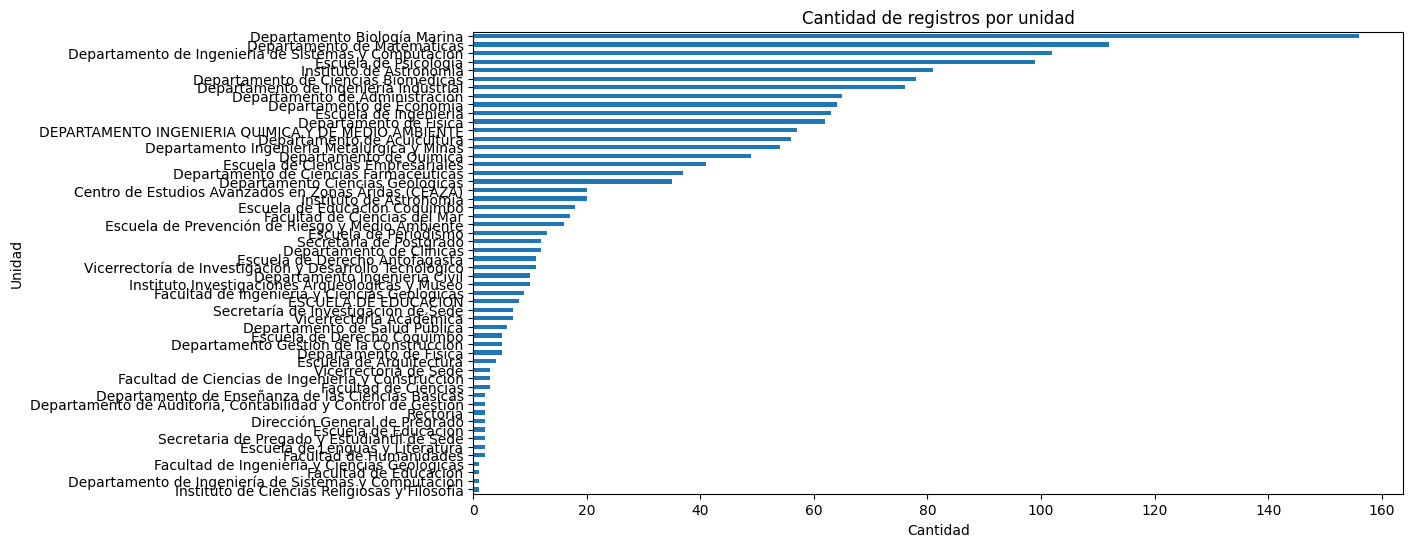

In [35]:
data_group = data.groupby("unidad").size().sort_values(ascending=True)

data_group.plot(kind="barh", figsize=(12,6))
plt.title("Cantidad de registros por unidad")
plt.xlabel("Cantidad")
plt.ylabel("Unidad")
plt.show()

In [40]:
wos_mask = data["wos_researcher_id"].notna()
scopus_mask = data["scopus_author_id"].notna()

total_wos = wos_mask.sum()
total_scopus = scopus_mask.sum()
en_ambas = (wos_mask & scopus_mask).sum()

print("Total en WoS:", total_wos)
print("Total en Scopus:", total_scopus)
print("Total en ambas:", en_ambas)

Total en WoS: 660
Total en Scopus: 1328
Total en ambas: 650


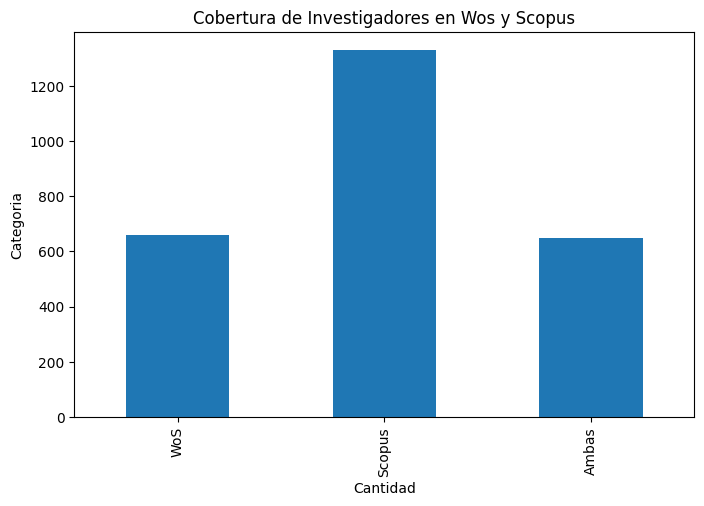

In [42]:

resumen = pd.Series({
    "WoS": total_wos,
    "Scopus": total_scopus,
    "Ambas": en_ambas})

resumen.plot(kind="bar", figsize=(8,5))
plt.title("Cobertura de Investigadores en Wos y Scopus")
plt.xlabel("Cantidad")
plt.ylabel("Categoria")
plt.show()